### House price prediction using linear ragression 

### Step 1: Import Required Libraries
# Import Libraries

In this step, the required Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn are imported. These libraries are used for data loading, preprocessing, visualization, and analysis.

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset
# Load Dataset

In this step, the House Price dataset is loaded into a Pandas DataFrame from a CSV file. This allows us to perform analysis on the data.

In [2]:
import pandas as pd

df = pd.read_csv("house price.csv") 

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Step 3: Select Important Features
# Select Required Columns

In this step, we select only the required columns from the dataset. These features are used for data analysis and predicting the house sale price. Keeping only the necessary columns makes the dataset simpler and easier to work with.

In [2]:
df = df[['OverallQual',
         'GrLivArea',
         'GarageCars',
         'TotalBsmtSF',
         'FullBath',
         'YearBuilt',
         'BedroomAbvGr',
         'SalePrice']]

### step 4: Undersatnd the Dataset 
# Dataset Information

In this step, we check the dataset information such as data types and number of columns.

In [3]:
df.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,BedroomAbvGr,SalePrice
0,7,1710,2,856,2,2003,3,208500
1,6,1262,2,1262,2,1976,3,181500
2,7,1786,2,920,2,2001,3,223500
3,7,1717,3,756,1,1915,3,140000
4,8,2198,3,1145,2,2000,4,250000


# Check Dataset Shape

In this step, we use the `shape` attribute to check the number of rows and columns in the dataset. It helps us understand the size and dimensions of the selected data.

In [4]:
df.shape

(1460, 8)

# Check Missing Values

In this step, we check whether the dataset contains missing values.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   OverallQual   1460 non-null   int64
 1   GrLivArea     1460 non-null   int64
 2   GarageCars    1460 non-null   int64
 3   TotalBsmtSF   1460 non-null   int64
 4   FullBath      1460 non-null   int64
 5   YearBuilt     1460 non-null   int64
 6   BedroomAbvGr  1460 non-null   int64
 7   SalePrice     1460 non-null   int64
dtypes: int64(8)
memory usage: 91.4 KB


# Display Statistical Summary

In this step, we use the describe() function to display the statistical summary of the numerical columns in the dataset. It provides information such as count, mean, standard deviation, minimum value, maximum value, and quartiles, which helps us understand the distribution of the data.

In [6]:
df.describe()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,BedroomAbvGr,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,1057.429452,1.565068,1971.267808,2.866438,180921.195890
std,1.382997,525.480383,0.747315,438.705324,0.550916,30.202904,0.815778,79442.502883
min,1.000000,334.000000,0.000000,0.000000,0.000000,1872.000000,0.000000,34900.000000
25%,5.000000,1129.500000,1.000000,795.750000,1.000000,1954.000000,2.000000,129975.000000
50%,6.000000,1464.000000,2.000000,991.500000,2.000000,1973.000000,3.000000,163000.000000
75%,7.000000,1776.750000,2.000000,1298.250000,2.000000,2000.000000,3.000000,214000.000000
max,10.000000,5642.000000,4.000000,6110.000000,3.000000,2010.000000,8.000000,755000.000000


### Step 5: Exploratory Data Analysis (EDA)

# Correlation Matrix
# Correlation Analysis

In this step, we use the `corr()` function to calculate the correlation between the numerical columns in the dataset. It helps us understand the strength and direction of the relationship between different features and the target variable (SalePrice).

In [7]:
df.corr()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,BedroomAbvGr,SalePrice
OverallQual,1.000000,0.593007,0.600671,0.537808,0.550600,0.572323,0.101676,0.790982
GrLivArea,0.593007,1.000000,0.467247,0.454868,0.630012,0.199010,0.521270,0.708624
GarageCars,0.600671,0.467247,1.000000,0.434585,0.469672,0.537850,0.086106,0.640409
TotalBsmtSF,0.537808,0.454868,0.434585,1.000000,0.323722,0.391452,0.050450,0.613581
FullBath,0.550600,0.630012,0.469672,0.323722,1.000000,0.468271,0.363252,0.560664
YearBuilt,0.572323,0.199010,0.537850,0.391452,0.468271,1.000000,-0.070651,0.522897
BedroomAbvGr,0.101676,0.521270,0.086106,0.050450,0.363252,-0.070651,1.000000,0.168213
SalePrice,0.790982,0.708624,0.640409,0.613581,0.560664,0.522897,0.168213,1.000000


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
# Plot Histograms

In this step, we create histograms for all the selected numerical features using the hist() function. The figsize parameter sets the size of the plots, and plt.show() displays the histograms. These graphs help us understand the distribution of each feature and identify any skewness or unusual values in the dataset.

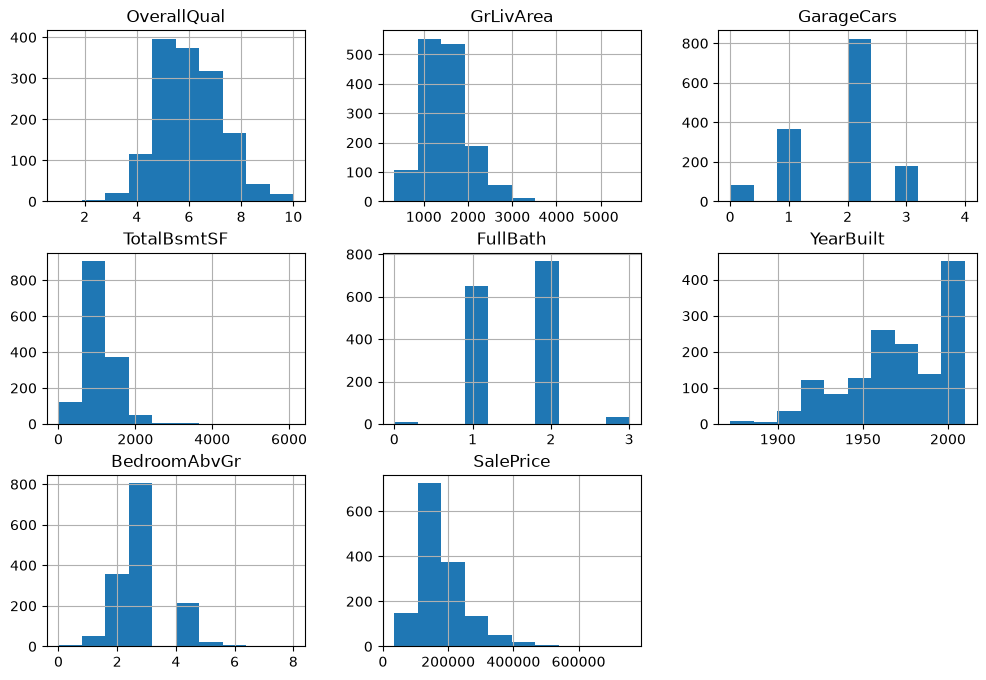

In [9]:
df.hist(figsize=(12,8))
plt.show()

# Heatmap
# Plot Correlation Heatmap

In this step, we create a correlation heatmap using the heatmap() function from the Seaborn library. The corr() function calculates the correlation between the numerical features, while annot=True displays the correlation values inside each cell. The cmap="coolwarm" parameter applies a color scheme to make the relationships easier to understand, and plt.show() displays the heatmap.

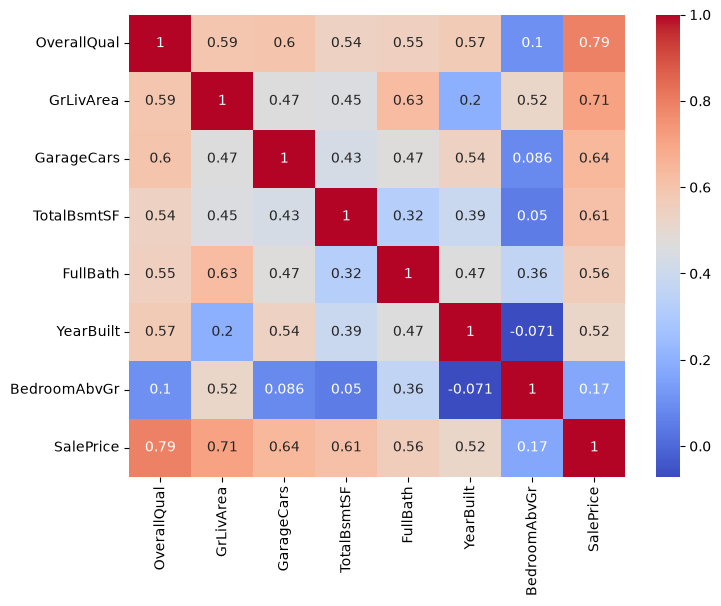

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# Scatter plot

In this step, we create a scatter plot to visualize the relationship between *GrLivArea* (Ground Living Area) and *SalePrice*. The xlabel() and ylabel() functions are used to label the x-axis and y-axis, while plt.show() displays the graph. This plot helps us understand how the living area affects the house sale price.


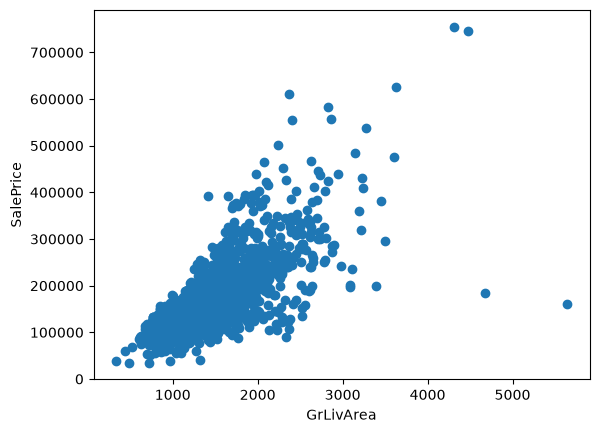

In [11]:
plt.scatter(df["GrLivArea"], df["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

### Step 6: Split Features and Target
# Separate Features and Target Variable

In this step, we separate the dataset into **features (X)** and the **target variable (y)**. The `SalePrice` column is removed from the feature set and stored separately as the target variable. This prepares the data for building a machine learning model.

In [12]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

### Step 8: Train-Test Split
# Split the Dataset into Training and Testing Sets

In this step, we import the train_test_split function from sklearn.model_selection and split the dataset into training and testing sets. The test_size=0.2 parameter means that 20% of the data is used for testing and 80% is used for training. The random_state=42 parameter ensures that the data is split in the same way every time the code is executed


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 9: Train the Linear Regression Model
# Train the Linear Regression Model

In this step, we import the LinearRegression model from sklearn.linear_model. Then, we create an instance of the Linear Regression model and train it using the training data (X_train and y_train) with the fit() function. This allows the model to learn the relationship between the input features and the target variable (SalePrice).


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[19520.48, 58.58,14703.77,...,-3568.02, 340.72,-6704.46]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['OverallQual','GrLivArea','GarageCars',...,'FullBath','YearBuilt', 'BedroomAbvGr']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.248e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


# Make Predictions

In this step, we use the trained Linear Regression model to predict the house sale prices for the testing dataset (X_test). The predicted values are stored in the y_pred variable, which will be used to evaluate the model's performance.

In [15]:
y_pred = model.predict(X_test)

### step 10: Prediction and Model Evaluation
# Evaluate the Model Performance

In this step, we import the `r2_score` function from `sklearn.metrics` to evaluate the performance of the Linear Regression model. The `r2_score()` function compares the actual values (`y_test`) with the predicted values (`y_pred`) and calculates the R² score. Finally, the score is displayed using the `print()` function.

In [16]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.8017169412958243


# Calculate Error Metrics

In this step, we import the mean_absolute_error and mean_squared_error functions from sklearn.metrics and the NumPy library. We calculate the *Mean Absolute Error (MAE), **Mean Squared Error (MSE), and **Root Mean Squared Error (RMSE)* to evaluate the performance of the Linear Regression model. Finally, the calculated values are displayed using the print() function.

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 25089.122530904362
MSE: 1520895741.6198626
RMSE: 38998.663331194606


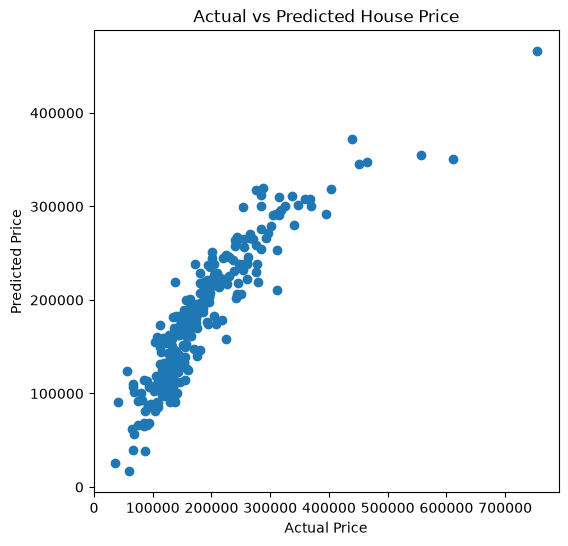

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

### step 11: Conclusion & Future Scope

# Project Summary

A Linear Regression model was developed to predict house prices based on important features such as OverallQual, GrLivArea, GarageCars, TotalBsmtSF, FullBath, YearBuilt, and BedroomAbvGr. The project included data loading, data preprocessing, exploratory data analysis (EDA), model training, prediction, and evaluation.

# Model Performance
R² Score: 80.17%
MAE: 25089.12
RMSE: 38998.66

# Key Findings
OverallQual has a strong impact on house prices.
GrLivArea and GarageCars are also important features.
The Linear Regression model predicts house prices with good accuracy.

# Limitations
Linear Regression assumes a linear relationship between features and house price.
The dataset may not include all factors affecting house prices.
Prediction accuracy may decrease for unseen data.

# Future Scope
Apply advanced regression models such as Random Forest and XGBoost.
Use a larger dataset with more house features.
Compare different regression models to find the best-performing model.